In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sedov solution

gamma = 5.0/3.0

A = (gamma + 1)/2


In [2]:
def denominator(xi, F, U):

    return (
        (gamma - 1)**2 * gamma * F**(gamma - 2)
        +
        4*xi**2*(U - A*xi)**3
    )

In [3]:
def dU_dxi(xi, F, U):

    D = denominator(xi, F, U)

    term1 = (
        (gamma - 1)**2
        * F**(gamma - 2)
        * (
            1.5*(gamma + 1)*xi
            - 2*gamma*U
        )
    )

    term2 = (
        3*(gamma + 1)
        * xi**3
        * U
        * (U - A*xi)**2
    )

    return (1/xi)*(term1/D + term2/D)

In [4]:
def dF_dxi(xi, F, U):

    D = denominator(xi, F, U)

    part1 = (
        1.5*(gamma + 1)
        * (gamma - 1)**2
        * F**(gamma - 2)
    )

    part2 = (
        xi
        * U
        * (8*U - (gamma + 1)*xi)
        * (U - A*xi)**2
    )

    bracket = part1/D + part2/D

    return -F/(U - A*xi)*bracket

In [5]:
def system(xi, y):

    F = y[0]
    U = y[1]

    return np.array([
        dF_dxi(xi, F, U),
        dU_dxi(xi, F, U)
    ])

In [6]:
sqrt21 = np.sqrt(21.0)

def rk6_step(x, y, h):

    k1 = h*system(x, y)

    k2 = h*system(
        x + h,
        y + k1
    )

    k3 = h*system(
        x + h/2,
        y + (3*k1 + k2)/8
    )

    k4 = h*system(
        x + 2*h/3,
        y + (8*k1 + 2*k2 + 8*k3)/27
    )

    k5 = h*system(
        x + (7 - sqrt21)*h/14,
        y + (
            3*(3*sqrt21 - 7)*k1
            - 8*(7 - sqrt21)*k2
            + 48*(7 - sqrt21)*k3
            - 3*(21 - sqrt21)*k4
        )/392
    )

    k6 = h*system(
        x + (7 + sqrt21)*h/14,
        y + (
            -5*(231 + 51*sqrt21)*k1
            -40*(7 + sqrt21)*k2
            -320*sqrt21*k3
            +3*(21 + 121*sqrt21)*k4
            +392*(6 + sqrt21)*k5
        )/1960
    )

    k7 = h*system(
        x + h,
        y + (
            15*(22 + 7*sqrt21)*k1
            +120*k2
            +40*(7*sqrt21 - 5)*k3
            -63*(3*sqrt21 - 2)*k4
            -14*(49 + 9*sqrt21)*k5
            +70*(7 - sqrt21)*k6
        )/180
    )

    y_next = y + (
        9*k1
        +64*k3
        +49*k5
        +49*k6
        +9*k7
    )/180

    return y_next

In [10]:
h = -1e-5

xi_values = [1.0]

F_values = [1.0]

U_values = [1.0]

y = np.array([1.0, 1.0])

xi = 1.0

In [11]:
while xi > 1e-4:

    y = rk6_step(xi, y, h)

    xi += h

    xi_values.append(xi)

    F_values.append(y[0])

    U_values.append(y[1])

In [12]:
G_values = []

for xi, F, U in zip(xi_values, F_values, U_values):

    rhs = (1 - gamma)/(2*xi**3)

    factor = (
        F**(1-gamma)
        *
        (U/xi - (gamma+1)/2)
    )

    G = rhs/factor

    G_values.append(G)

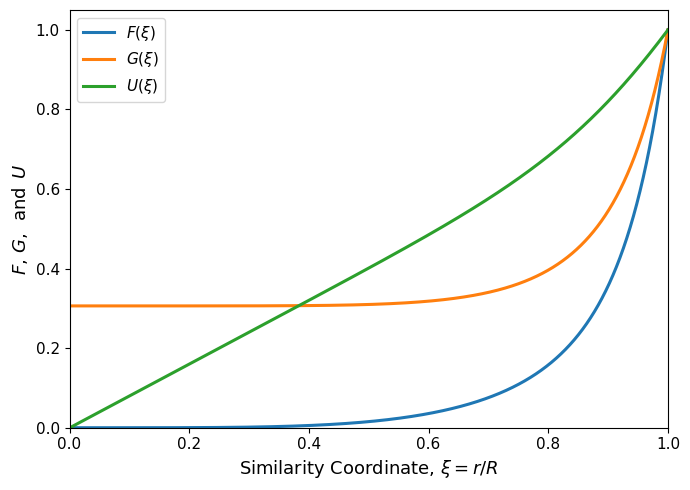

In [13]:
plt.figure(figsize=(7,5))

plt.plot(
    xi_values,
    F_values,
    linewidth=2.2,
    label=r'$F(\xi)$'
)

plt.plot(
    xi_values,
    G_values,
    linewidth=2.2,
    label=r'$G(\xi)$'
)

plt.plot(
    xi_values,
    U_values,
    linewidth=2.2,
    label=r'$U(\xi)$'
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.xlabel(
    r'Similarity Coordinate, $\xi=r/R$',
    fontsize=13
)

plt.ylabel(
    r'$F,\,G,\,$ and $\,U$',
    fontsize=13
)

plt.tick_params(
    axis='both',
    labelsize=11
)

plt.legend(
    fontsize=11,
    frameon=True
)

plt.grid(False)

plt.tight_layout()


plt.savefig(
    "Figure1_Sedov_profiles.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

In [14]:
xi_values = np.array(xi_values)

F_values = np.array(F_values)

G_values = np.array(G_values)

U_values = np.array(U_values)

In [15]:
kinetic_integrand = (
    (1/(gamma-1))
    * F_values
    * U_values**2
    * xi_values**2
)

thermal_integrand = (
    (1/(gamma-1))
    * G_values
    * xi_values**2
)

In [16]:
T = abs(
    np.trapezoid(
        kinetic_integrand,
        xi_values
    )
)

Ug = abs(
    np.trapezoid(
        thermal_integrand,
        xi_values
    )
)

print("T =", T)
print("Ug =", Ug)

T = 0.09255213185825253
Ug = 0.23477000252008698


In [17]:
total = T + Ug

T_frac = T/total

Ug_frac = Ug/total

In [18]:
integrand = (
    (1/(gamma-1))
    * F_values
    * U_values**2
    +
    (1/(gamma-1))
    * G_values
)

integrand *= xi_values**2

I = abs(
    np.trapezoid(
        integrand,
        xi_values
    )
)


In [19]:
B_minus5 = (
    32*np.pi
    /
    (25*(gamma+1))
) * I

B = (1/B_minus5)**(1/5)


In [20]:
print("="*40)

print("Sedov Solution Results")

print("="*40)

print(f"B       = {B:.6f}")

print(f"T/E     = {T_frac:.6f}")

print(f"Ug/E    = {Ug_frac:.6f}")

print("="*40)

Sedov Solution Results
B       = 1.151666
T/E     = 0.282755
Ug/E    = 0.717245
